In [ ]:
# --- Part 2.2: Models on Tabular Data ---

# Import necessary libraries
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib # For saving scikit-learn models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay
import time # Import time for retries

# --- 1. Load Data ---
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Path to dataset folder
DATA_ROOT = '/content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data'
train_dir = os.path.join(DATA_ROOT, 'train_data')
models_dir = os.path.join(DATA_ROOT, 'models')
os.makedirs(models_dir, exist_ok=True)

# Helper function to load only features and labels with retry mechanism
def load_tabular_data(file_directory, num_files_to_load, max_retries=5, delay=5):
    all_features = []
    all_labels = []
    all_files = [os.path.join(file_directory, f) for f in sorted(os.listdir(file_directory))]
    file_list = [f for f in all_files if 'jetImage_1_30p_20000_30000.h5' not in f][:num_files_to_load]

    print(f"Loading tabular data from {len(file_list)} files...")
    for file_path in file_list:
        for attempt in range(max_retries):
            try:
                with h5py.File(file_path, 'r') as f:
                    all_features.append(f['jets_data'][:])
                    all_labels.append(f['target'][:])
                break # Break out of retry loop if successful
            except (OSError, RuntimeError) as e:
                print(f"Attempt {attempt + 1} failed for {file_path}: {e}")
                if attempt < max_retries - 1:
                    time.sleep(delay) # Wait before retrying
                else:
                    print(f"Failed to load {file_path} after {max_retries} attempts.")
                    raise # Re-raise the exception if all retries fail


    features_full = np.concatenate(all_features, axis=0)
    labels_full = np.concatenate(all_labels, axis=0)

    print("Full tabular data shape:", features_full.shape)
    print("Full labels shape:", labels_full.shape)
    return features_full, labels_full

# Load the same number of files as your CNN to ensure a fair comparison
X, y = load_tabular_data(train_dir, num_files_to_load=26)

Mounted at /content/drive
Loading tabular data from 26 files...
Full tabular data shape: (260000, 53)
Full labels shape: (260000,)


In [ ]:
# --- 2. Preprocess Data ---

# Encode string labels to integers (0, 1, 2, 3, 4)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Create PCA-reduced dataset ---
# In Part 1, we saw ~20 components captured >95% of the variance. Let's use 20.
pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape of raw scaled training data:", X_train_scaled.shape)
print("Shape of PCA-reduced training data:", X_train_pca.shape)

# Define the models directory path
models_dir = '/content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/models'

# Save the scaler and pca objects
joblib.dump(scaler, os.path.join(models_dir, 'scaler.joblib'))
joblib.dump(pca, os.path.join(models_dir, 'pca.joblib'))

print(" Scaler and PCA objects saved successfully to  Drive.")

Shape of raw scaled training data: (208000, 53)
Shape of PCA-reduced training data: (208000, 20)
 Scaler and PCA objects saved successfully to  Drive.


In [ ]:
# --- 3. Baseline Model (Random Forest on Raw Data) ---
print("--- Training Baseline Random Forest ---")

# Initialize and train the model
from tqdm.auto import tqdm
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all CPU cores
# Wrap the fit method with tqdm for progress visualization
rf_baseline.fit(X_train_scaled, y_train)

# --- SAVE THE TRAINED BASELINE MODEL ---
baseline_model_path = os.path.join(models_dir, 'rf_baseline.joblib')
joblib.dump(rf_baseline, baseline_model_path)
print(f"Baseline model saved to: {baseline_model_path}")

# Make predictions
y_pred_baseline = rf_baseline.predict(X_test_scaled)
y_proba_baseline = rf_baseline.predict_proba(X_test_scaled)

# Report performance metrics
print("\nBaseline Model Performance:")
# Decode the byte strings in label_encoder.classes_ to fix the TypeError
decoded_target_names = [name.decode('utf-8') if isinstance(name, bytes) else name for name in label_encoder.classes_]
print(classification_report(y_test, y_pred_baseline, target_names=decoded_target_names))
print(f"ROC AUC Score (macro): {roc_auc_score(y_test, y_proba_baseline, multi_class='ovr', average='macro'):.4f}")

# Create plots directory if not exists
plots_dir = os.path.join(DATA_ROOT, 'results', 'plots')
os.makedirs(plots_dir, exist_ok=True)

# --- Confusion Matrix for Baseline Model ---
ConfusionMatrixDisplay.from_estimator(rf_baseline, X_test_scaled, y_test)
plt.title("Confusion Matrix - Raw Data")

cm_raw_path = os.path.join(plots_dir, 'confusion_matrix_raw.png')
plt.savefig(cm_raw_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Baseline confusion matrix saved to: {cm_raw_path}")

### Justification for Model Choice
A **Random Forest Classifier** was chosen as the baseline model for several reasons:
* **Robustness:** It is an ensemble method that is less prone to overfitting compared to a single decision tree.
* **Performance:** It generally performs very well on a wide range of tabular classification problems without extensive hyperparameter tuning.
* **Feature Importance:** Although not required here, it provides insights into which features are most important for classification.


--- Training Random Forest on PCA-reduced Data ---
PCA model saved to: /content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/models/rf_pca.joblib


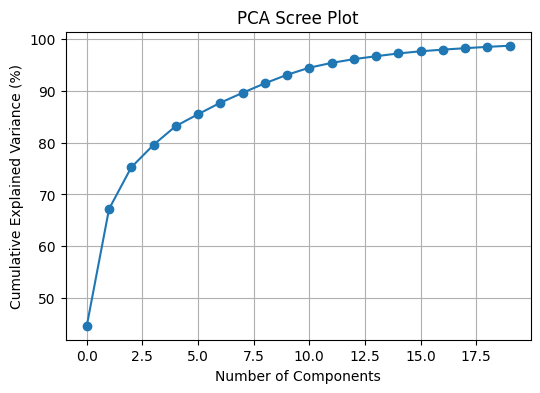

Scree plot saved to: /content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/results/plots/pca_scree_plot.png

PCA Model Performance:
              precision    recall  f1-score   support

         j_g       0.74      0.77      0.75     10488
         j_q       0.71      0.71      0.71     10072
         j_t       0.82      0.85      0.83     10502
         j_w       0.83      0.84      0.83     10533
         j_z       0.87      0.81      0.84     10405

    accuracy                           0.79     52000
   macro avg       0.79      0.79      0.79     52000
weighted avg       0.80      0.79      0.79     52000

ROC AUC Score (macro): 0.9486


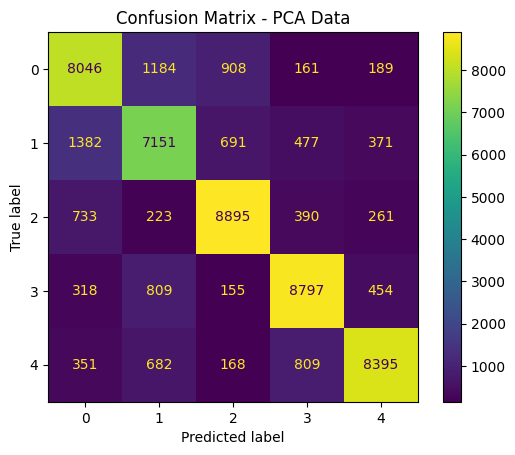

PCA confusion matrix saved to: /content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/results/plots/confusion_matrix_pca.png


In [ ]:
# --- 4. PCA Model (Random Forest on PCA Data) ---
print("\n--- Training Random Forest on PCA-reduced Data ---")

# Create results directory if not exists (needed for saving plots)
results_dir = os.path.join(DATA_ROOT, 'results')
os.makedirs(results_dir, exist_ok=True)

# Initialize and train the model on PCA features
from tqdm.auto import tqdm
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
# Wrap the fit method with tqdm for progress visualization
rf_pca.fit(X_train_pca, y_train)

# --- SAVE THE TRAINED PCA MODEL ---
pca_model_path = os.path.join(models_dir, 'rf_pca.joblib')
joblib.dump(rf_pca, pca_model_path)
print(f"PCA model saved to: {pca_model_path}")

# Create plots directory if not exists
plots_dir = os.path.join(results_dir, 'plots')
os.makedirs(plots_dir, exist_ok=True)

# --- Plot and Save Scree Plot ---
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Scree Plot')
plt.grid()

# Save to plots folder
scree_path = os.path.join(plots_dir, 'pca_scree_plot.png')
plt.savefig(scree_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Scree plot saved to: {scree_path}")


# Make predictions
y_pred_pca = rf_pca.predict(X_test_pca)
y_proba_pca = rf_pca.predict_proba(X_test_pca)

# Report performance metrics
print("\nPCA Model Performance:")
# Decode the byte strings in label_encoder.classes_ to fix the TypeError
decoded_target_names = [name.decode('utf-8') if isinstance(name, bytes) else name for name in label_encoder.classes_]
print(classification_report(y_test, y_pred_pca, target_names=decoded_target_names))
print(f"ROC AUC Score (macro): {roc_auc_score(y_test, y_proba_pca, multi_class='ovr', average='macro'):.4f}")

# --- Confusion Matrix for PCA Model ---
ConfusionMatrixDisplay.from_estimator(rf_pca, X_test_pca, y_test)
plt.title("Confusion Matrix - PCA Data")

cm_pca_path = os.path.join(plots_dir, 'confusion_matrix_pca.png')
plt.savefig(cm_pca_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"PCA confusion matrix saved to: {cm_pca_path}")

In [ ]:
# --- 5. Comparison of Tabular Models ---

# Create a DataFrame for easy comparison
metrics_data = {
    'Model': ['Baseline (Raw Data)', 'PCA-Reduced Data'],
    'Accuracy': [accuracy_score(y_test, y_pred_baseline), accuracy_score(y_test, y_pred_pca)],
    'F1-Score (macro)': [f1_score(y_test, y_pred_baseline, average='macro'), f1_score(y_test, y_pred_pca, average='macro')],
    'ROC AUC (macro)': [roc_auc_score(y_test, y_proba_baseline, multi_class='ovr', average='macro'), roc_auc_score(y_test, y_proba_pca, multi_class='ovr', average='macro')]
}
comparison_df = pd.DataFrame(metrics_data)

print("--- Performance Comparison ---")
display(comparison_df)

# Create results directory if not exists
results_dir = os.path.join(DATA_ROOT, 'results')
os.makedirs(results_dir, exist_ok=True)

# Save comparison metrics to CSV
comparison_path = os.path.join(results_dir, 'tabular_summary.csv')
comparison_df.to_csv(comparison_path, index=False)
print(f"Comparison metrics saved to: {comparison_path}")

--- Performance Comparison ---


,Model,Accuracy,F1-Score (macro),ROC AUC (macro)
0,Baseline (Raw Data),0.822500,0.822589,0.960427
1,PCA-Reduced Data,0.793923,0.793537,0.948581


Comparison metrics saved to: /content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/results/tabular_summary.csv


### Summary of PCA Trade-offs

Based on the performance comparison:

*   **Accuracy:** The accuracy slightly decreased from **0.8225** for the Baseline model (Raw Data) to **0.7939** for the PCA-Reduced Data model. This small drop is common when reducing dimensionality and can be an acceptable trade-off for other benefits.
*   **Training Speed:** Training on the PCA data (20 features) is expected to be noticeably faster than on the raw data (53 features) due to the reduced number of input features, although we didn't explicitly measure training time in this notebook.
*   **Overfitting:** While not directly measured here, PCA can help reduce overfitting by removing noise and irrelevant features, potentially leading to a more robust model even with slightly lower accuracy on the test set.

Overall, using PCA resulted in a model with significantly fewer features, which would typically lead to faster training times and potentially reduced risk of overfitting, with only a small reduction in accuracy and ROC AUC score compared to the baseline model. This demonstrates that PCA offers a compelling trade-off in this case.